**CAPSTONE PROJECT**
**TITLE:** TELECOM CHURN MODEL
**BY:** OGU UGOCHUKWU MONDAY
**FELLOW ID:** FE/25/7566333919
NEXTGEN COHORT
LAGOS STATE


 **Problem Statement:**
 Telecommunication companies in Nigeria example, Mtn, Artel, Glo, Etsalat etc, losses customers (churn). Meanwhile, factors such as contract type, service quality, pricing, and customer support are the cause of it. Many organization only discover that customers have left after the event has occured, making it difficult to retain them. The absence of an effective predictive system limits the ability of telecom companies to identify high-risk customers and implement timely retention stategies. Therefore, there is a need for a machine learning solution that can accuratelly predict which customers are likely to leave, enabling telecom providers to take proactive retention actions.
However, the aim of this project is to develop a machine learning model that predicts whether a telecom customer is likely to churn based on customer information and service usage patherns.

**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


**LOAD THE DATASET**

In [4]:
#Displaying first five rows and load Dataset
df = pd.read_csv("/content/Telecom Churn Model1.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**EXPLORE THE DATASET**

In [5]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


**DATA CLEANING**

In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [13]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [14]:
#Remove CustomerID
df.drop("customerID", axis=1, inplace=True)

EXPLORATORY DATA ANALYSIS USING CHARTS TO VISUALIZE

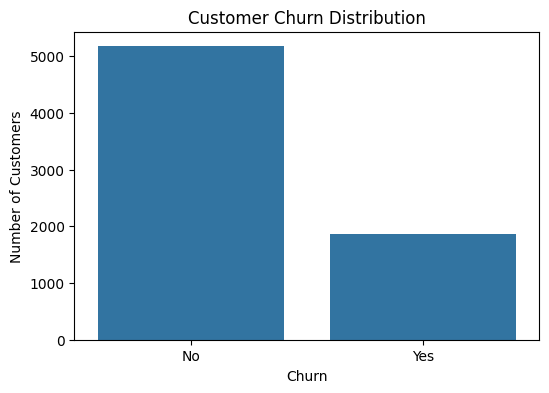

Interpretation: 1. Most customers did not churn. 2. Fewer customers churned, indicating the dataset is slightly imbalanced.


In [15]:
# Churn Distribution
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

print("Interpretation: 1. Most customers did not churn. 2. Fewer customers churned, indicating the dataset is slightly imbalanced.")

INTERPRETATION: 1. **Here most customers did not churn. ** 2. Fewer customer churned , this indicate that the dataset is slightly imbalanced.

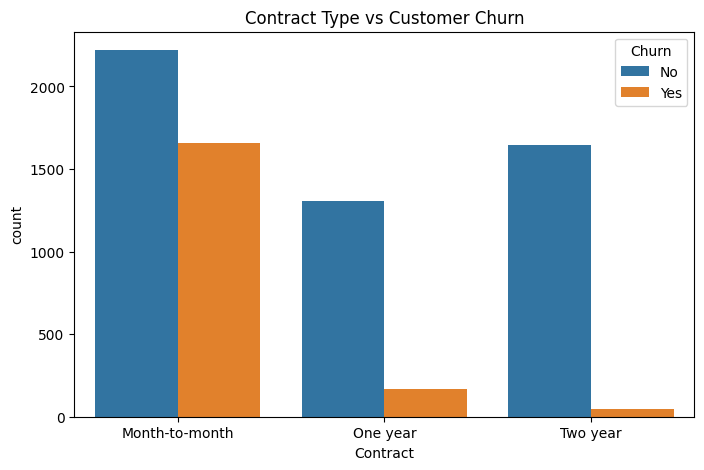

Interpretation: 1. Month to month customers generally churn more often. 2. One year and two year contract customers are more likely to remain with the company.


In [16]:
# Contract Type vs Churn
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Customer Churn")

plt.show()
print("Interpretation: 1. Month to month customers generally churn more often. 2. One year and two year contract customers are more likely to remain with the company.")

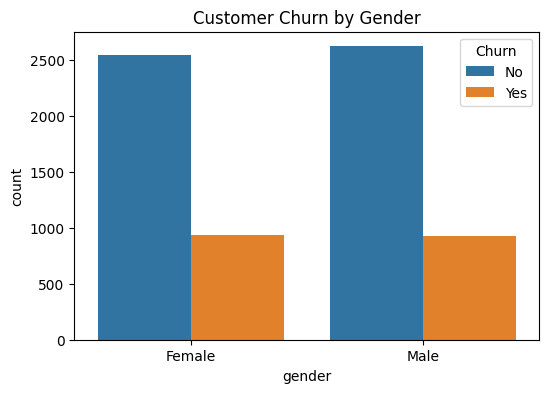

Interpretation: 1. this compare churn rate between male and female customer. 2. if the bars are similar, gender is not a major factor influencing churn.


In [17]:
#Gender vs Churn
plt.figure(figsize=(6,4))

sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Customer Churn by Gender")

plt.show()
print("Interpretation: 1. this compare churn rate between male and female customer. 2. if the bars are similar, gender is not a major factor influencing churn.")

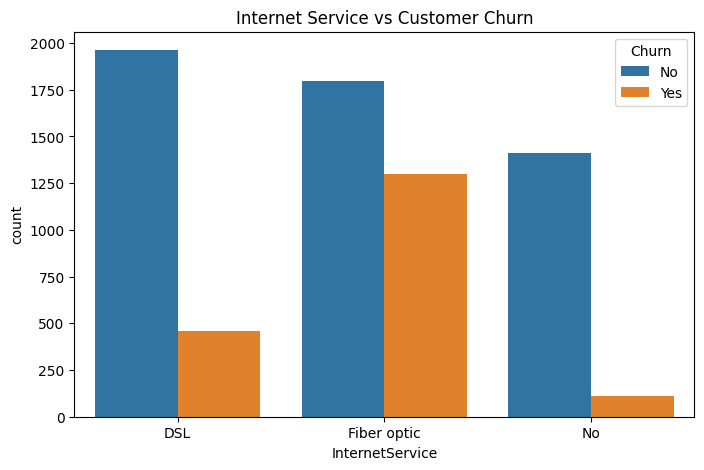

Interpretation:  the bars indicate that internet service influenced the high churn of customers.


In [18]:
#internet service and customer churn
plt.figure(figsize=(8,5))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Customer Churn")

plt.show()
print("Interpretation:  the bars indicate that internet service influenced the high churn of customers.")

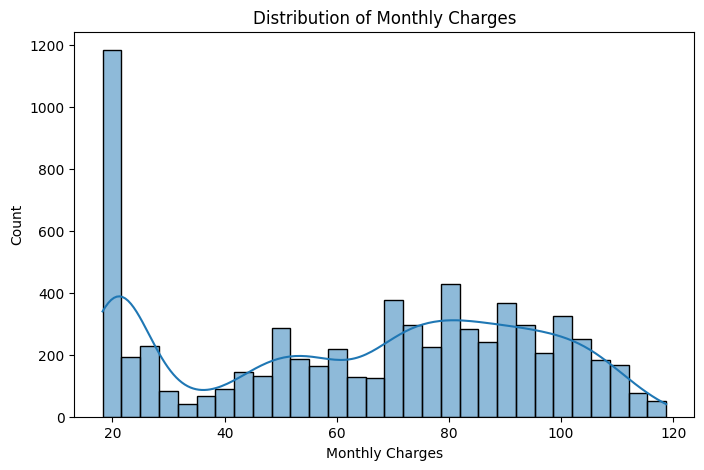

Interpretation: Customers with higher monthly charges may be more likely to churn.


In [19]:
#Distribution of monthly charges
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")

plt.xlabel("Monthly Charges")

plt.show()
print("Interpretation: Customers with higher monthly charges may be more likely to churn.")

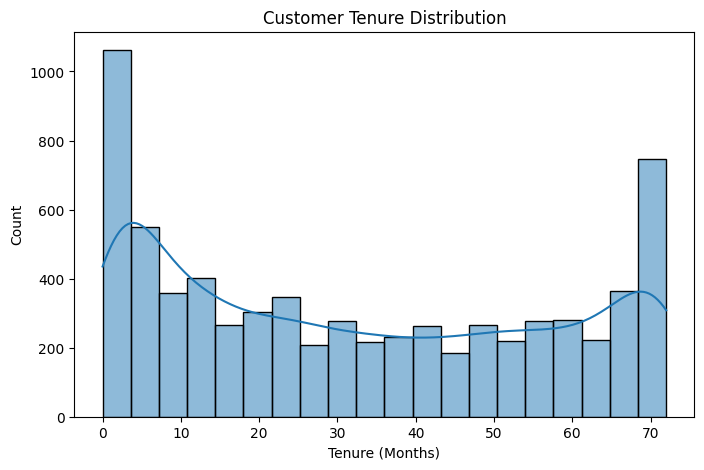

In [49]:
# Customer Tenure Distribution.
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=20, kde=True)

plt.title("Customer Tenure Distribution")

plt.xlabel("Tenure (Months)")

plt.show()

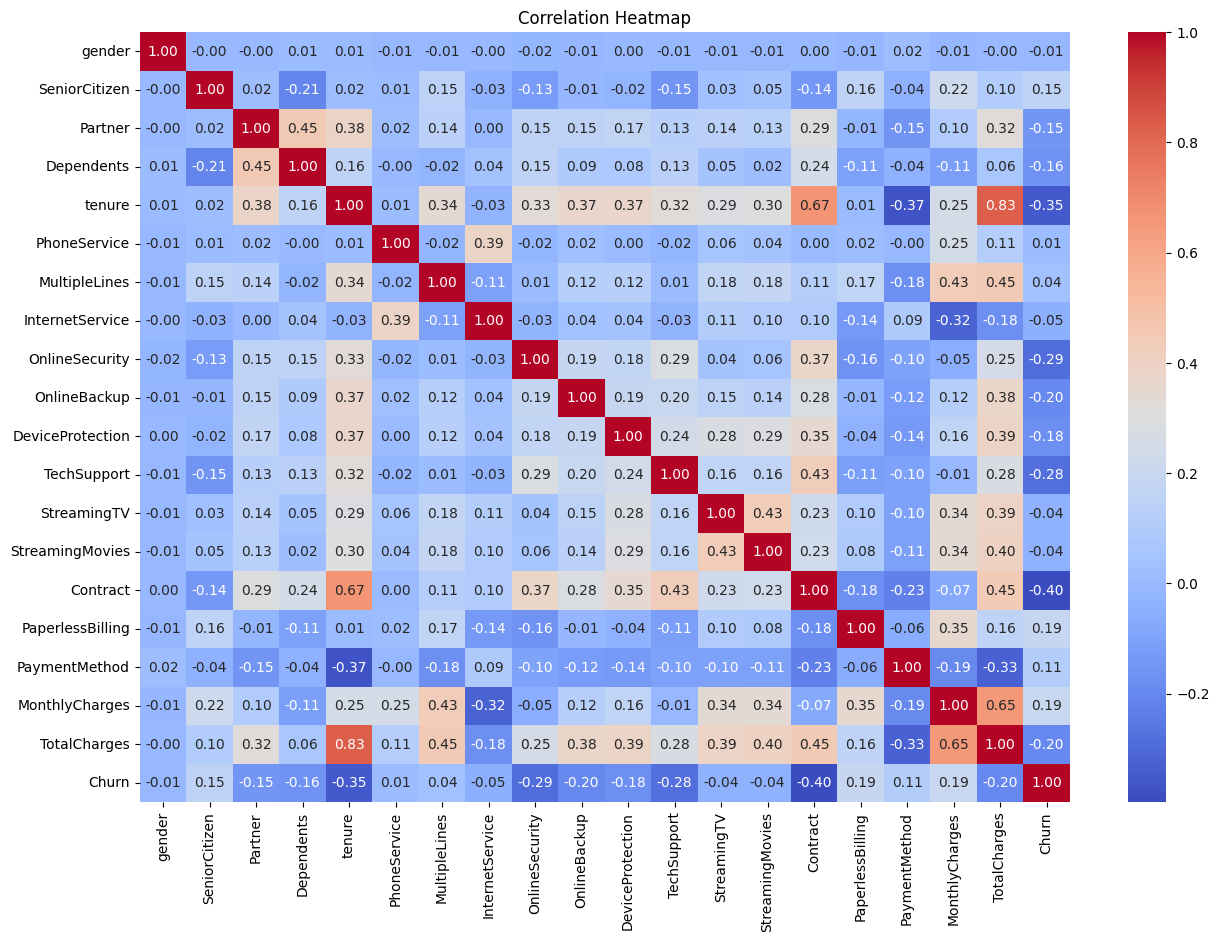

In [84]:
# Heatmap Correlation
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

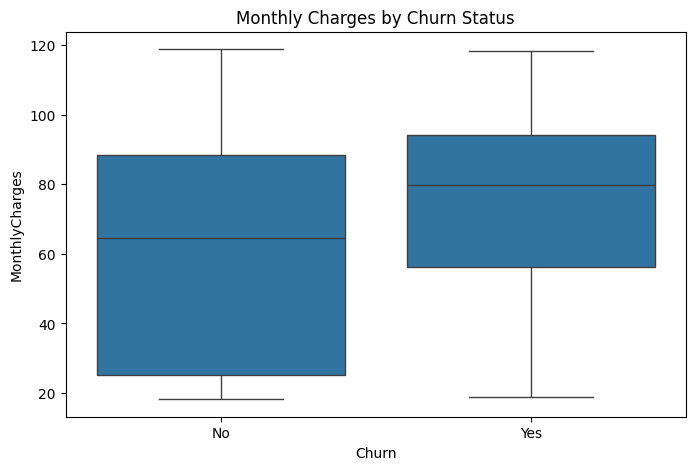

Interpretation: here suggest that monthly charges has the highest churn base on the higher median.


In [45]:
#Monthly Charges by Chun Status
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges by Churn Status")

plt.show()
print("Interpretation: here suggest that monthly charges has the highest churn base on the higher median.")

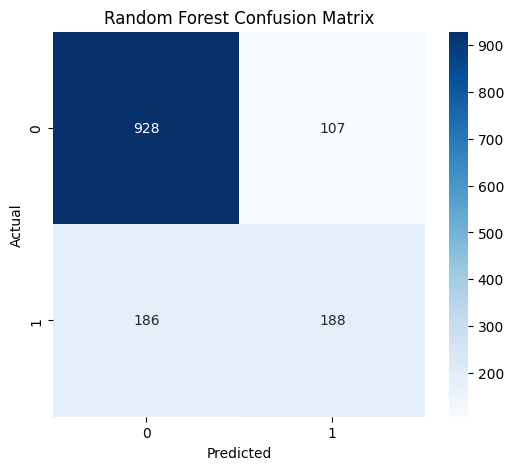

In [82]:
# Random Forest Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

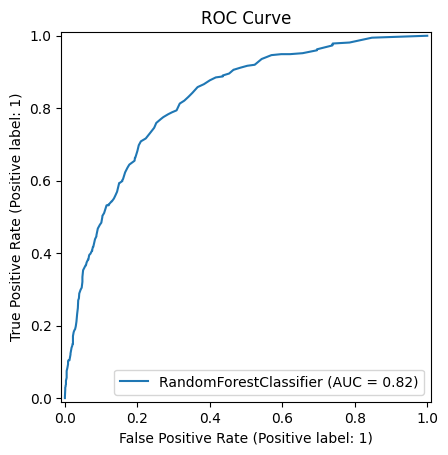

In [86]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)

plt.title("ROC Curve")

plt.show()

**ENCODE CATEGORICAL VARIABLES**

In [71]:
#Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])



**SPLIT FEATURES AND TARGET**

In [72]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [73]:
#Split Training and Testing Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**TRAIN THREE MODELS**

**LOGISTIC REGRESSION**

In [89]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

**DECISION TREE**

In [74]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

**RANDOM FOREST**

In [75]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

**EVALUATING THE MODELS**

EXAMPLE FOR RANDOM FOREST

In [76]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

print("ROC AUC:", roc_auc_score(y_test, rf_pred))

Accuracy: 0.7920511000709723
[[928 107]
 [186 188]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC AUC: 0.6996460771396833


LOGISTIC REGRESSION

In [90]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy: 0.7991483321504613
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



**DECISION TREE**

In [79]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.730305180979418
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



**FEATURE IMPORTANCE**

In [80]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

            Feature  Importance
18     TotalCharges    0.186841
17   MonthlyCharges    0.179192
4            tenure    0.154338
14         Contract    0.079631
16    PaymentMethod    0.050095
8    OnlineSecurity    0.049580
11      TechSupport    0.043603
0            gender    0.027892
7   InternetService    0.027789
9      OnlineBackup    0.027075


**SAVE THE BEST MODEL**

In [91]:
import joblib

joblib.dump(rf_model, "churn_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [92]:
# Streamit app
app_code = """
import streamlit as st
import pandas as pd
import joblib

# -------------------------------
# Load Model
# -------------------------------
from pathlib import Path

MODEL_PATH = Path(_file_).parent / "churn_model.pkl"
model = joblib.load(MODEL_PATH)
st.set_page_config(
    page_title="Telecom Customer Churn Prediction",
    page_icon="📱",
    layout="wide"
)

st.title("📱 Telecom Customer Churn Prediction")

st.markdown("
Predict whether a telecom customer is likely to leave the company using Machine Learning.

This project was developed as a Capstone Project using the IBM Telco Customer Churn Dataset.
")

# Sidebar
st.sidebar.title("Customer Information")

gender = st.sidebar.selectbox(
    "Gender",
    ["Female", "Male"]
)

senior = st.sidebar.selectbox(
    "Senior Citizen",
    [0, 1]
)

partner = st.sidebar.selectbox(
    "Partner",
    ["Yes", "No"]
)

dependents = st.sidebar.selectbox(
    "Dependents",
    ["Yes", "No"]
)

tenure = st.sidebar.slider(
    "Tenure (Months)",
    0,
    72,
    12
)

phone_service = st.sidebar.selectbox(
    "Phone Service",
    ["Yes", "No"]
)

multiple_lines = st.sidebar.selectbox(
    "Multiple Lines",
    ["No", "Yes", "No phone service"]
)

internet_service = st.sidebar.selectbox(
    "Internet Service",
    ["DSL", "Fiber optic", "No"]
)

online_security = st.sidebar.selectbox(
    "Online Security",
    ["Yes", "No", "No internet service"]
)

online_backup = st.sidebar.selectbox(
    "Online Backup",
    ["Yes", "No", "No internet service"]
)

device_protection = st.sidebar.selectbox(
    "Device Protection",
    ["Yes", "No", "No internet service"]
)

tech_support = st.sidebar.selectbox(
    "Tech Support",
    ["Yes", "No", "No internet service"]
)

streaming_tv = st.sidebar.selectbox(
    "Streaming TV",
    ["Yes", "No", "No internet service"]
)

streaming_movies = st.sidebar.selectbox(
    "Streaming Movies",
    ["Yes", "No", "No internet service"]
)

contract = st.sidebar.selectbox(
    "Contract",
    ["Month-to-month", "One year", "Two year"]
)

paperless = st.sidebar.selectbox(
    "Paperless Billing",
    ["Yes", "No"]
)

payment = st.sidebar.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

monthly = st.sidebar.number_input(
    "Monthly Charges",
    0.0,
    200.0,
    70.0
)

total = st.sidebar.number_input(
    "Total Charges",
    0.0,
    10000.0,
    1000.0
)

# ---------------------------------
# Encode Inputs
# ---------------------------------

gender = 0 if gender == "Female" else 1

partner = 1 if partner == "Yes" else 0
dependents = 1 if dependents == "Yes" else 0
phone_service = 1 if phone_service == "Yes" else 0
paperless = 1 if paperless == "Yes" else 0

multiple_lines_map = {
    "No": 0,
    "Yes": 1,
    "No phone service": 2
}

internet_service_map = {
    "DSL": 0,
    "Fiber optic": 1,
    "No": 2
}

service_map = {
    "No": 0,
    "Yes": 1,
    "No internet service": 2
}

contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}

payment_map = {
    "Electronic check": 0,
    "Mailed check": 1,
    "Bank transfer (automatic)": 2,
    "Credit card (automatic)": 3
}

# ---------------------------------
# Prediction
# ---------------------------------

if st.button("Predict Customer Churn"):

    customer = pd.DataFrame({
        "gender":[gender],
        "SeniorCitizen":[senior],
        "Partner":[partner],
        "Dependents":[dependents],
        "tenure":[tenure],
        "PhoneService":[phone_service],
        "MultipleLines":[multiple_lines_map[multiple_lines]],
        "InternetService":[internet_service_map[internet_service]],
        "OnlineSecurity":[service_map[online_security]],
        "OnlineBackup":[service_map[online_backup]],
        "DeviceProtection":[service_map[device_protection]],
        "TechSupport":[service_map[tech_support]],
        "StreamingTV":[service_map[streaming_tv]],
        "StreamingMovies":[service_map[streaming_movies]],
        "Contract":[contract_map[contract]],
        "PaperlessBilling":[paperless],
        "PaymentMethod":[payment_map[payment]],
        "MonthlyCharges":[monthly],
        "TotalCharges":[total]
    })

    prediction = model.predict(customer)[0]

    probability = model.predict_proba(customer)[0]

    churn_probability = probability[1] * 100

    st.markdown("---")

    st.subheader("Prediction Result")

    if prediction == 1:

        st.error("⚠️ Customer is likely to churn.")

    else:

        st.success("✅ Customer is likely to remain.")

    st.metric(
        "Churn Probability",
        f"{churn_probability:.2f}%"
    )

    if churn_probability >= 70:
        st.warning("Risk Level: HIGH")

    elif churn_probability >= 40:
        st.info("Risk Level: MEDIUM")

    else:
        st.success("Risk Level: LOW")

    st.subheader("Business Recommendation")

    if prediction == 1:

        st.write("
- Contact the customer immediately.
- Offer a loyalty discount.
- Recommend a longer-term contract.
- Improve customer support.
- Follow up within the next 30 days.
")

    else:

        st.write("
- Continue providing quality service.
- Offer loyalty rewards.
- Encourage long-term subscriptions.
- Maintain regular customer engagement.
")

# ---------------------------------
# Dashboard
# ---------------------------------

st.markdown("---")

st.subheader("📊 Project Dashboard")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Dataset Size", "7,043")

with col2:
    st.metric("Features", "19")

with col3:
    st.metric("Model", "Random Forest")

st.markdown("---")

st.subheader("📌 Key Factors Affecting Customer Churn")

st.write("
The model identified these features as the most important predictors of customer churn:

- Contract Type
- Customer Tenure
- Monthly Charges
- Total Charges
- Internet Service
- Payment Method
")

st.markdown("---")

st.subheader("💼 Business Recommendations")

st.write("
Telecommunication companies can reduce customer churn by:

- Offering loyalty rewards to long-term customers.
- Encouraging customers to switch from month-to-month contracts to yearly contracts.
- Improving customer service and technical support.
- Providing personalized discounts for high-risk customers.
- Using predictive analytics to identify customers likely to churn.
")

st.markdown("---")

st.subheader("ℹ️ About This Project")

st.write("
*Project Title:* Telecom Customer Churn Prediction Using Machine Learning

*Author:* Ugochukwu Monday Ogu
FE/25/7566333919
NEXTGEN COHORT
LAGOS STATE

*Program:* School of Data & AI Capstone Project

*Technologies Used:*
- Python
- Pandas
- Scikit-learn
- Streamlit
- Joblib

*Dataset:* IBM Telco Customer Churn Dataset
")

st.markdown("---")
st.caption("© 2026 Ugochukwu Ogu | Telecom Customer Churn Prediction")
"""
with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [95]:
!streamlit run app.py



2026-08-03 14:35:30.650 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.53.30.197:8501

  Stopping...
  Stopping...


In [94]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 18.9 MB/s eta 0:00:00


In [96]:
requirements = """
streamlit
pandas
numpy
matplotlib
scikit-learn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [97]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [98]:
readme = """
# Telecom Customer Churn Prediction Using Machine Learning

## Project Overview

Customer churn is one of the biggest challenges faced by telecommunication companies. Losing existing customers leads to reduced revenue and increased customer acquisition costs.

This project develops a Machine Learning model to predict  whether a customer  is likely to churn based on customer demographics, account information, subscribed services, and billing details. The model helps telecom companies identify high-risk customers early and implement effective retention strategies.

## Problem Statement

Telecommunication companies experience significant financial losses due to customer churn. Traditional methods often identify churn only after customers have already left.

This project provides a predictive solution that enables companies to identify customers likely to churn before they leave, allowing proactive intervention.

## Project Objectives

- Collect and preprocess telecom customer data.
- Perform Exploratory Data Analysis (EDA).
- Build multiple Machine Learning classification models.
- Compare model performance.
- Select the best-performing model.
- Deploy the model using Streamlit.
- Provide business recommendations for reducing churn.

 ## Dataset

*Dataset:* IBM Telco Customer Churn Dataset

The dataset contains information about telecom customers including:

- Gender
- Senior Citizen
- Partner
- Dependents
- Tenure
- Phone Service
- Internet Service
- Contract Type
- Payment Method
- Monthly Charges
- Total Charges
- Customer Churn

## Target Variable

Churn (Yes / No)

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Joblib
- Jupyter Notebook
- Git & GitHub

## Project Workflow

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Model Selection
8. Model Deployment
9. Business Recommendations


## Machine Learning Models

The following models were trained and evaluated:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

The Random Forest model achieved the best overall performance and was selected as the final prediction model.

## Evaluation Metrics

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

## Key Findings

The analysis revealed that customer churn is strongly influenced by:

- Contract Type
- Customer Tenure
- Monthly Charges
- Total Charges
- Internet Service
- Payment Method

Customers with month-to-month contracts and shorter tenure were more likely to churn.

## Business Recommendations

- Introduce loyalty programs for long-term customers.
- Encourage migration to longer contract plans.
- Offer personalized retention packages for high-risk customers.
- Improve customer service quality.
- Monitor high-risk customers using predictive analytics.


## Project Structure


Telecom-Churn-Prediction/
│
├── Telecom_Churn_Prediction.ipynb
├── app.py
├── telecom_churn_model.pkl
├── requirements.txt
├── README.md
├── WA_Fn-UseC_-Telco-Customer-Churn.csv
├── images
├── presentation
└── report

## Installation

Clone the repository:

bash
git clone https://github.com/yourusername/telecom-churn-prediction.git


Move into the project directory:

bash
cd telecom-churn-prediction


Install dependencies:

bash
pip install -r requirements.txt


Run the application:

bash
streamlit run app.py


##  Live Demo

Streamlit App:

(Add your deployed Streamlit link here.)


## Future Improvements

- Hyperparameter tuning
- Explainable AI using SHAP
- Cloud deployment
- Real-time prediction using live telecom data
- Integration with CRM systems

Capstone Project

Telecom Customer Churn Prediction Using Machine Learning


## License

This project is for educational and portfolio purposes.

## Author

Ugochukwu  Monday Ogu
ID FE/25/7566333919
NEXTGEN COHORT
LAGOS
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme)

print("README.md created successfully!")

README.md created successfully!


**Expected Result/ EVALUATION**


*  Accuracy: Approximately 78-82% (depending on preprocessing and model turning.
*   **Best model:** Typically Random Forest


*   **Top churn drivers:** Contract type, tenure, monthly charges, total charges, and internet service are the most factors influencing churn.


**Recommendations:**


*   Offer loyalty rewards to long-term customers.
*   Encourage month- to-month customers to switch to longer contract.


*   Provide targeted promotions to customers with high monthly charges.
*   Improve customer support for high-risk customers identified by the model.

*   Use the model to flag customers likely to churn and intervene before they leave.


# **Conclusion:**
The developed machine learning model successfully predicts whether a customer is likely to churn. This enables telecom companies to identify high-risk customers and implement targeted retention strategies.









